frame_times:  [   2.946891    5.759051    8.571569   11.384224   14.196374   17.009075
   19.821396   22.634259   25.446544   28.25893    31.071764   33.88418
   36.69646    39.509209   42.321618   45.133891   47.946628   50.759274
   53.571646   56.384214   59.196875   62.009113   64.821703   67.634025
   70.446646   73.258922   76.071755   78.884083   81.696846   84.509299
   87.321524   90.134164   92.946635   95.759241   98.571924  101.384132
  104.19673   107.009303  109.821622  112.634184  115.446814  118.259098
  121.07165   123.884504  126.696952  129.509263  132.321835  135.134428
  137.946959  140.759552  143.571993  146.38455   149.197168  152.009858
  154.82219   157.634674  160.447214  163.259748  166.072653  168.88516
  171.697312  174.50975   177.32238   180.135156  182.947527  185.759869
  188.572459  191.385218  194.197816  197.010891  199.822678  202.635262
  205.448146  208.260503  211.072874  213.885599  216.697799  219.510451
  222.322913  225.135856  227.948715  2

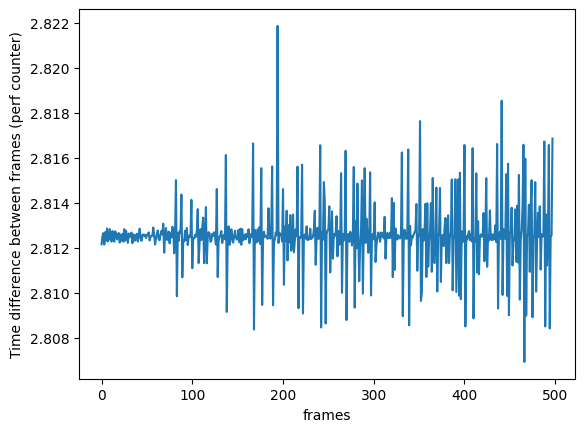

In [1]:
#############################
# Import Forest1 json info #
############################
import json
from glob import glob
import numpy as np
import os
from pathlib import Path
import matplotlib.pyplot as plt

base_path = Path('/Users/clairenastaskin/data/2025-06-24/sub-Forest001_ses-20250624_task-movements_run-002')  
Forest1_info_file = base_path / "*pwd.json"
# Get the json file path using glob
info_file_path = glob(str(Forest1_info_file))[0]

# Read the json file
with open(info_file_path, 'r') as f:
    info = json.load(f)

frame_times = info['VolumeTiming']
frame_times = np.array(frame_times)
print('frame_times: ', frame_times)

diff_perf = np.diff(frame_times)
fig, ax = plt.subplots()
ax.plot(diff_perf)
ax.set_ylabel('Time difference between frames (perf counter)')
ax.set_xlabel('frames')
t_r = np.median(diff_perf)
t_r

# Save t_r value to base_path
np.save(os.path.join(base_path, 't_r.npy'), t_r)
fig.savefig(base_path / "time_between_frame.png")